# CPU Benchmark Results Analysis
Aggregating data from different model runs, ignoring `inter` to simulate multiple runs per `(ranks, intra)` configuration.

In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all results.csv from the benchmarks directory
base_dir = '/hpcwork/ro092286/smartsim/cpu_benchmark/benchmarks'
csv_files = glob.glob(os.path.join(base_dir, '*_mini_app_*', 'results.csv')) + \
            glob.glob(os.path.join(base_dir, '*_mmcp_*', 'results.csv'))

dfs = []
for f in csv_files:
    model_folder = os.path.basename(os.path.dirname(f))
    if 'mini_app' in model_folder:
        model_name = model_folder.split('_mini_app')[0]
    elif 'mmcp' in model_folder:
        model_name = model_folder.split('_mmcp')[0]
    else:
        model_name = model_folder.split('_')[0]
        
    try:
        df = pd.read_csv(f)
        df['model'] = model_name
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {f}: {e}")

df_all = pd.concat(dfs, ignore_index=True)

# Filter successful runs
df_succ = df_all[df_all['status'] == 'SUCCESS'].copy()

# Group by model, ranks, intra to compute means across inter (which we treat as identical runs)
df_agg = df_succ.groupby(['model', 'ranks', 'intra']).agg({
    'time_s': ['mean', 'std', 'count'],
    'max_rss_mb': 'mean'
}).reset_index()

# Flatten multi-level columns
df_agg.columns = ['model', 'ranks', 'intra', 'time_mean', 'time_std', 'measurements', 'memory_mean']
df_agg.head()

,model,ranks,intra,time_mean,time_std,measurements,memory_mean
0,giant,1,1,422.93336,0.200158,5,6842.848
1,giant,1,2,213.19426,1.541065,5,6824.364
2,giant,1,4,113.63100,0.218620,5,6823.650
3,giant,1,8,59.17980,0.335094,5,6842.236
4,giant,1,16,34.17762,0.224201,5,6890.806


## Execution Time Heatmaps

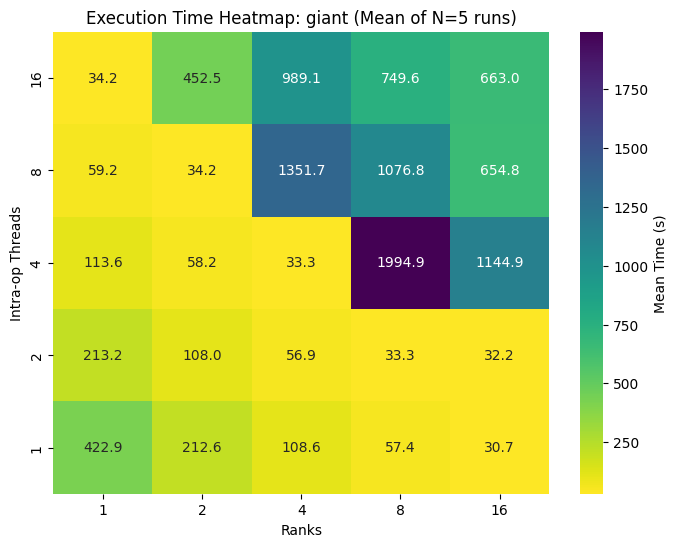

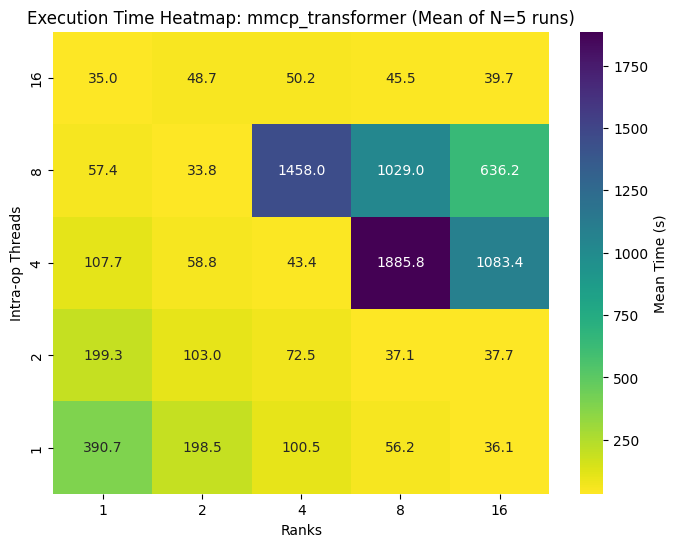

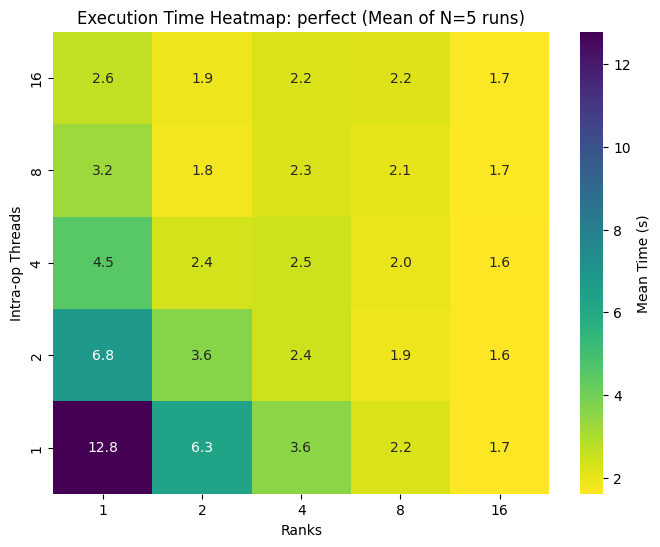

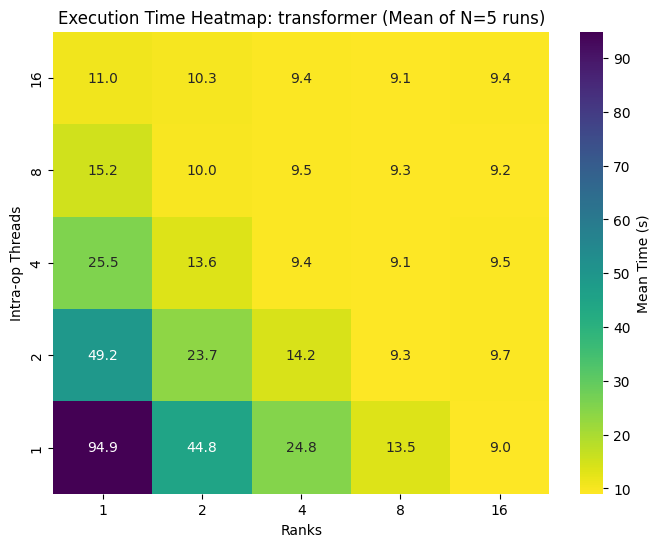

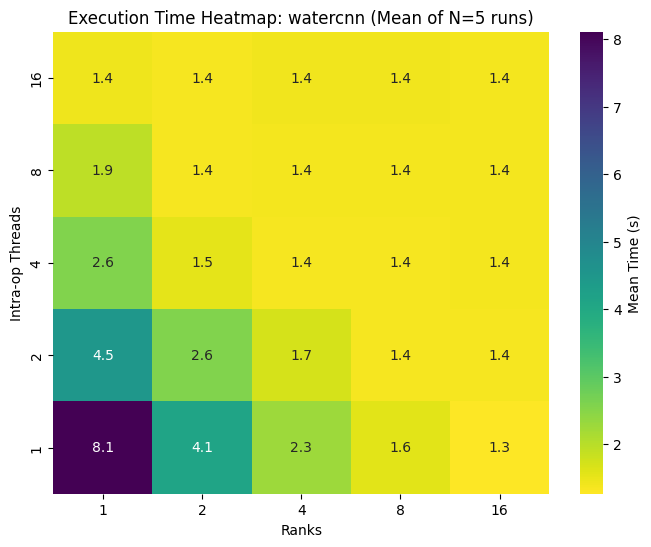

In [9]:
models = df_agg['model'].unique()

for model in models:
    plt.figure(figsize=(8, 6))
    df_model = df_agg[df_agg['model'] == model]
    pivot_table = df_model.pivot(index='intra', columns='ranks', values='time_mean')
    
    # Sort indices just in case so they display logically
    pivot_table = pivot_table.sort_index(ascending=False) 
    
    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='viridis_r', cbar_kws={'label': 'Mean Time (s)'})
    plt.title(f"Execution Time Heatmap: {model} (Mean of N={int(df_model['measurements'].max())} runs)")
    plt.xlabel('Ranks')
    plt.ylabel('Intra-op Threads')
    plt.show()

## Memory Usage

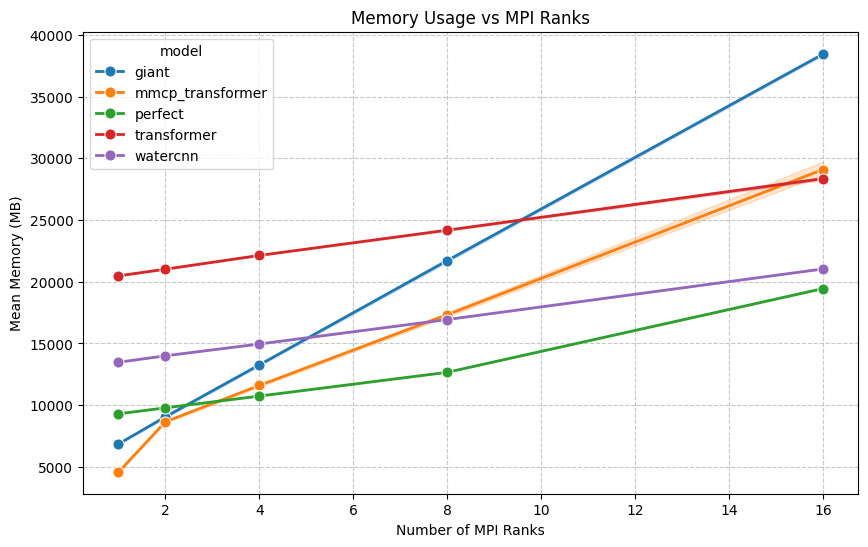

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_agg, x='ranks', y='memory_mean', hue='model', marker='o', linewidth=2, markersize=8)
plt.title('Memory Usage vs MPI Ranks')
plt.xlabel('Number of MPI Ranks')
plt.ylabel('Mean Memory (MB)')
plt.grid(True, ls='--', alpha=0.7)
plt.show()